In [2]:
## Install required libraries
!pip install -q imbalanced-learn xgboost

## Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import zipfile
uploaded = files.upload()



## ML tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb


with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall(".")

df = pd.read_csv("PS_20174392719_1491204439457_log.csv")
print("✅ Data loaded successfully!")


Saving archive.zip to archive (2).zip
✅ Data loaded successfully!


In [3]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

In [4]:
## EDA of dataset

print("• DATASET SHAPE: ", df.shape)
print("\n •COLUMN NAMES: \n", df.columns.tolist())
print("\n •MISSING VALUES: \n", df.isnull().sum())
print("\n •DATA TYPES: \n", df.dtypes)

print("\n •DESCRIPTIVE STATISTICS: \n", df.describe())

print("\n •FRAUD COUNT: \n")
print(df['isFraud'].value_counts())

print("\n •FRAUD PERCENTAGE: \n")
print(round(df['isFraud'].value_counts(normalize=True) * 100,2))

print("\n •TRANSACTION TYPES: \n", df['type'].value_counts())

print("\n •CORRELATION WITH TARGET (isFraud): \n")
print(df.corr(numeric_only=True)['isFraud'].sort_values(ascending=False))



• DATASET SHAPE:  (6362620, 11)

 •COLUMN NAMES: 
 ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

 •MISSING VALUES: 
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

 •DATA TYPES: 
 step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

 •DESCRIPTIVE STATISTICS: 
                step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+

In [5]:
## Data Preprocessing

#Drop irrelevant columns for fraud detection
X = df.drop(['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest'], axis=1)
y = df['isFraud']

# Encode categorical column "type"
le = LabelEncoder()
X['type'] = le.fit_transform(X['type'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n✅ Train-Test Split Done!")

# Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\n✅ After SMOTE: Fraud/Non-Fraud Balance")
print(y_train_res.value_counts())


✅ Train-Test Split Done!

✅ After SMOTE: Fraud/Non-Fraud Balance
isFraud
0    5083503
1    5083503
Name: count, dtype: int64


In [6]:
## Train Model

# Using XGBoost (powerful for fraud detection)
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_res, y_train_res)

# Predictions
y_pred = model.predict(X_test)

print("\n✅ Model Training Done!")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:54:17] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Model Training Done!


✅ Accuracy: 0.9976864876418834

📊 Classification Report:

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270904
       Fraud       0.35      0.99      0.52      1620

    accuracy                           1.00   1272524
   macro avg       0.68      0.99      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524



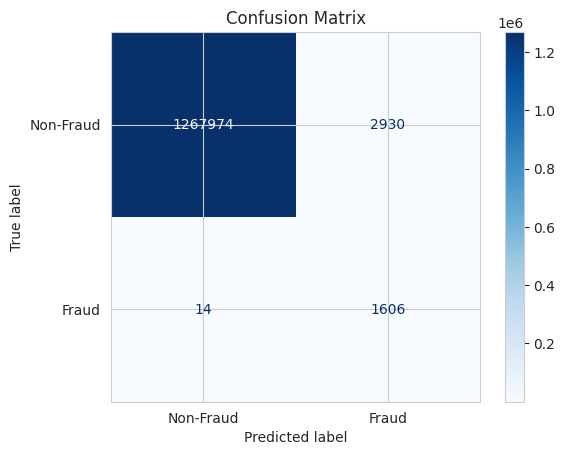

In [7]:
## Evaluate Results
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("✅ Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Non-Fraud", "Fraud"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Fraud", "Fraud"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


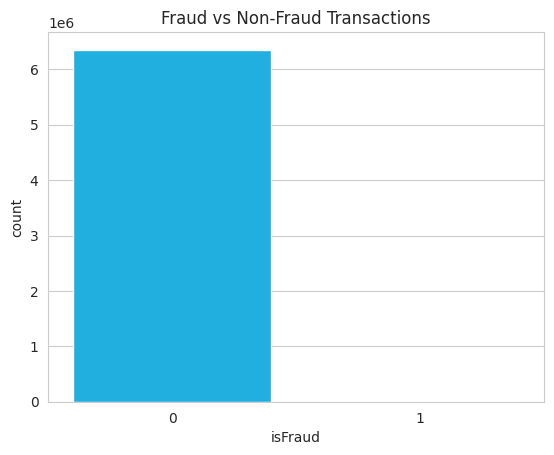

In [8]:
##Class Imbalance - Fraud datasets are highly imbalanced. A simple countplot showing fraud vs non-fraud immediately communicates this.

sns.countplot(x='isFraud', data=df, color='deepskyblue')
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()


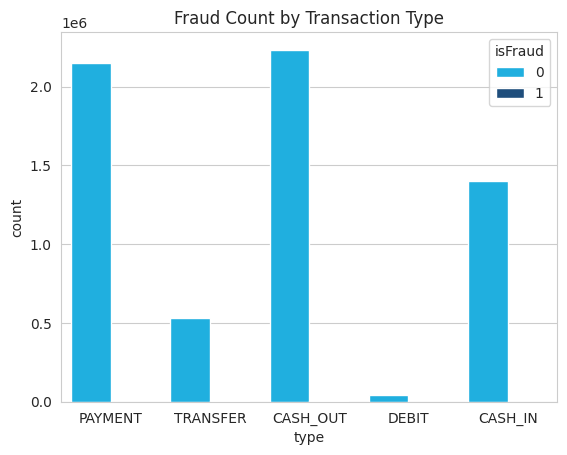

In [9]:
## Fraud by Transaction Type

sns.countplot(x='type', hue='isFraud', data=df, palette={0:"#00BFFF", 1:"#104E8B"})
plt.title('Fraud Count by Transaction Type')
plt.show()
